In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

df = pd.read_csv('/Users/jgd/Downloads/student-mat.csv', sep=';')

# orignally ran this and saw a bunch of columns separated by ; but it was 
# getting interpreted as one, so used ; as delimiter

pd.set_option('display.max_columns', None)

df.head(10)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15


In [2]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [3]:
# Right away, I notice an outlier for abscences which is the numerical column that
# can have the most variation in value
# 75 percentile for attendance is 8 but max is 75, certainly an outlier or misinput
# reasonable to drop the .5% highest values for absences
old_df = df

# new filtered data frame
df= df[df['absences'] <= df['absences'].quantile(0.995)]

print(len(old_df) - len(df)) 
print("rows were removed")

2
rows were removed


In [4]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

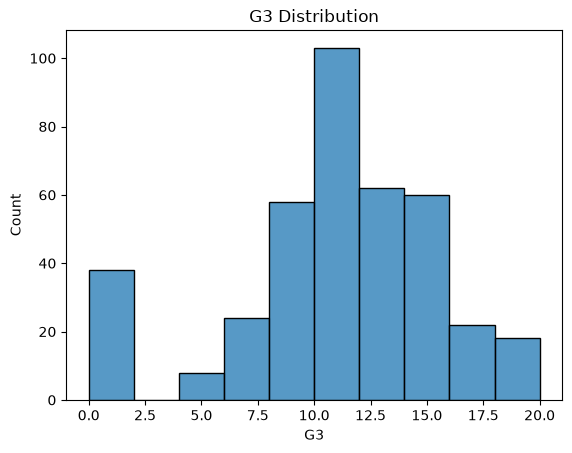

In [5]:
sns.histplot(df['G3'], bins=10)
plt.title("G3 Distribution")
plt.show()

In [6]:
# it is clear here that there are either some extreme outliers
# cases that students dropped course or gavve up
# or misinput
# worth noting that these could be legitimate


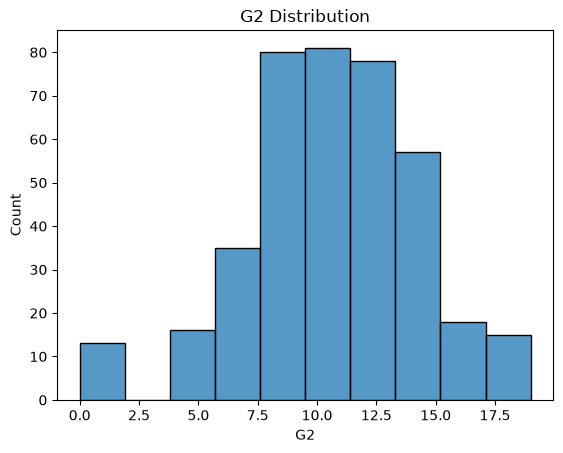

In [7]:
sns.histplot(df['G2'], bins=10)
plt.title("G2 Distribution")
plt.show()

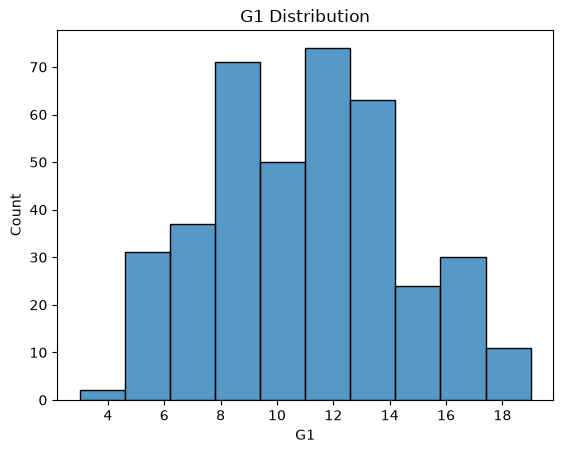

In [8]:
sns.histplot(df['G1'], bins=10)
plt.title("G1 Distribution")
plt.show()

In [9]:
# worth noting: there are around the same amount of students in the 17-20 range 
# across g1,g2,g3

# also, the grades in g1, beginning of year, are more spread out
# more students grades become average (10-12) as the school year progresses

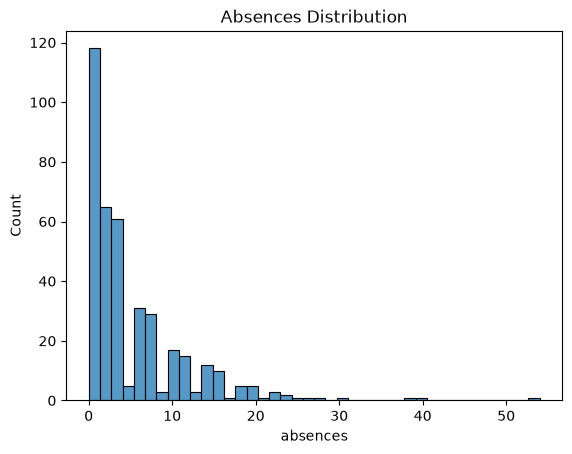

In [10]:
sns.histplot(df['absences'], bins=40)
plt.title("Absences Distribution")
plt.show()

In [11]:
# it is clear most students keep very few absences,
# interstingly quick drop off of number of students having high absences

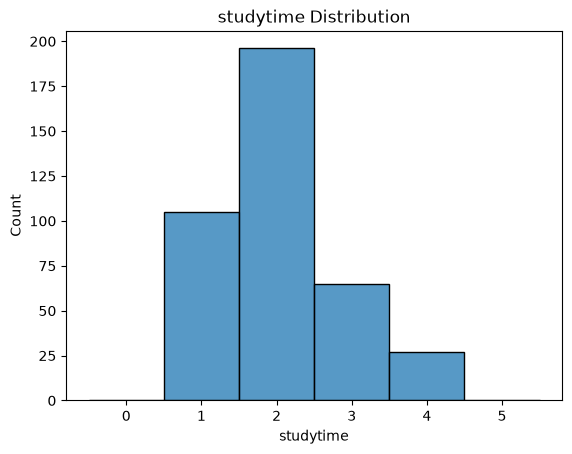

In [12]:
sns.histplot(df['studytime'], bins=5, discrete=True, binrange=(0,5))
plt.title("studytime Distribution")
plt.show()

In [13]:
# students on average could use more time to study, or they choose not to
# study as much as they should

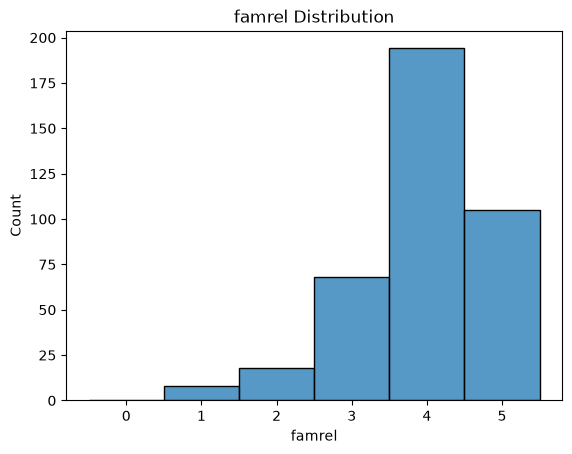

In [14]:
sns.histplot(df['famrel'], bins=5, discrete=True, binrange=(0,5))
plt.title("famrel Distribution")
plt.show()

In [15]:
# most students maintain really good family relations, which can help
# with education and support emotional, etc

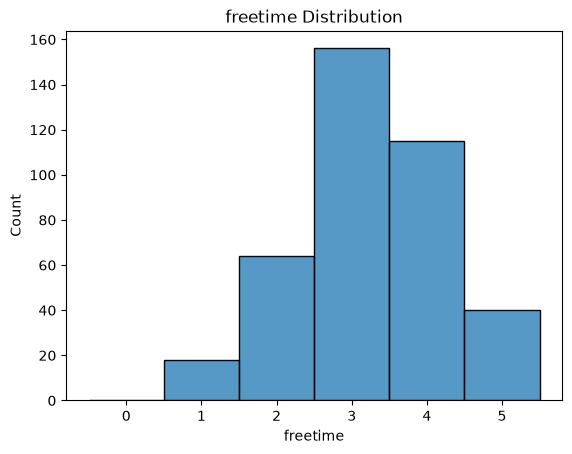

In [16]:
sns.histplot(df['freetime'], bins=5, discrete=True, binrange=(0,5))
plt.title("freetime Distribution")
plt.show()

In [17]:
#students are more likely to have decent amounts of free time, expected

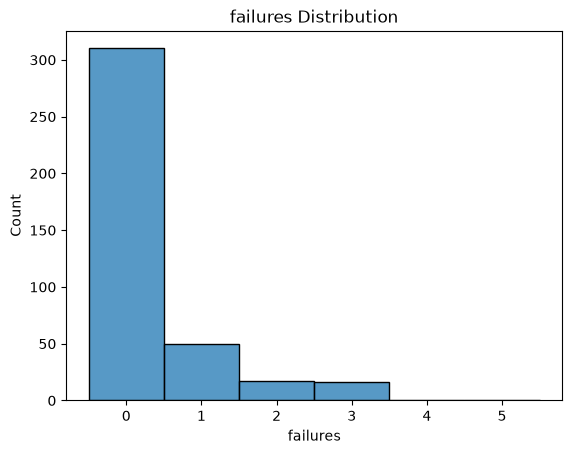

In [18]:
sns.histplot(df['failures'], bins=5, discrete=True, binrange=(0,5))
plt.title("failures Distribution")
plt.show()

In [19]:
# most students havent failed before, interesting

<Axes: >

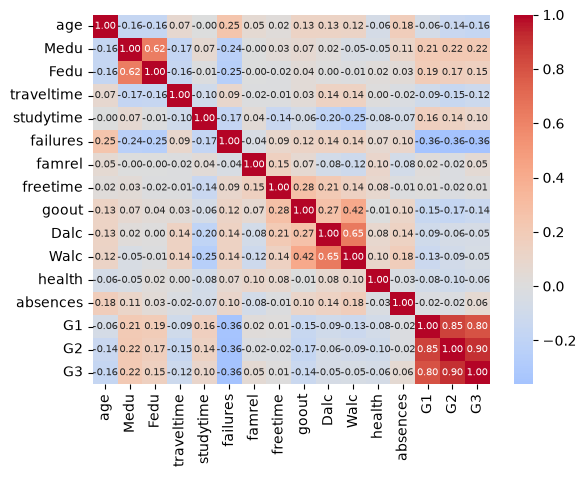

In [20]:

sns.heatmap(df.corr(numeric_only=True), annot = True, fmt='.2f', cmap="coolwarm", center=0, annot_kws={'size': 7})


In [21]:
# fathers education and mothers education show some correaltion with G3
# fathers has highercorrelation though
# failures also has negative correlation, highest overall indicator
# alcohol usage has almost no correlation
# and surprisingly neither to absences


In [22]:
# onto categorical

In [32]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    variance = df.groupby(col)['G3'].median().std()
    nunique = df[col].nunique()
    print(f"{col}: variance={variance:.5f}, unique={nunique}")


school: variance=0.70711, unique=2
sex: variance=0.35355, unique=2
address: variance=0.70711, unique=2
famsize: variance=0.00000, unique=2
Pstatus: variance=0.00000, unique=2
Mjob: variance=1.09545, unique=5
Fjob: variance=1.34164, unique=5
reason: variance=0.50000, unique=4
guardian: variance=0.86603, unique=3
schoolsup: variance=0.70711, unique=2
famsup: variance=0.00000, unique=2
paid: variance=0.00000, unique=2
activities: variance=0.00000, unique=2
nursery: variance=0.00000, unique=2
higher: variance=2.12132, unique=2
internet: variance=0.70711, unique=2
romantic: variance=0.00000, unique=2


/var/folders/ct/5s044xss2cq8hpsbhfzknhbw0000gn/T/ipykernel_16188/35203237.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()
